[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/08_sequences_series_convergence/first_principles.ipynb)

# Module 08 — Sequences, Series and Convergence

From one axiom about $\mathbb{R}$ to the tests that decide whether an infinite sum is a number at all.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

import math
from scipy import special

print("numpy", np.__version__)

numpy 2.4.6


## 1. Why This Module Exists

Addition is a binary operation. Induction extends it to any *finite* list. Nothing in
arithmetic tells you what $a_1 + a_2 + a_3 + \cdots$ means when the list never ends, and
the naive answers are contradictory: grouping $1 - 1 + 1 - 1 + \cdots$ as $(1-1)+(1-1)+\cdots$
gives $0$, while grouping it as $1 - (1-1) - (1-1) - \cdots$ gives $1$.

The resolution is to stop treating an infinite sum as a sum and start treating it as a
**limit of finite sums**. That single move converts every question about infinite summation
into a question about the convergence of a sequence, and convergence of sequences is decided
by one structural fact about $\mathbb{R}$ — completeness. Everything in this module is
downstream of that fact.

This matters far outside pure analysis. Every iterative algorithm produces a sequence of
states and asks whether it settles. A reinforcement-learning agent's value is an infinite
discounted sum. A stochastic-gradient schedule is admissible exactly when one series diverges
and another converges. A Neumann expansion $(I - A)^{-1} = \sum_k A^k$ is a matrix geometric
series, and it is a valid identity only under a convergence hypothesis. A truncated series
evaluated in floating point stops improving at a predictable term index. In each case the
engineering question is the analysis question: does the partial-sum sequence converge, and
how fast.

The module builds the machinery in dependency order: completeness $\to$ monotone convergence
$\to$ Bolzano-Weierstrass $\to$ the Cauchy criterion $\to$ series $\to$ the convergence tests
$\to$ absolute versus conditional convergence.

## 2. Intuition

A series is a race between two effects. The terms $a_n$ shrink, which pulls the increments
toward zero; but there are infinitely many of them, which pushes the total up. Convergence is
the statement that shrinking wins.

The decisive quantity is not "how small is $a_n$" but "how small is the *tail*
$\sum_{k \gt N} a_k$". Terms can go to zero and still lose the race: the harmonic terms
$1/n$ vanish, yet the blocks
$\tfrac{1}{2}$, $\tfrac{1}{3}+\tfrac{1}{4}$, $\tfrac{1}{5}+\cdots+\tfrac{1}{8}$
each weigh at least $\tfrac{1}{2}$, and there are infinitely many blocks.

Two mental pictures carry most of the module.

**Picture one — the staircase.** Plot the partial sums $S_N$ against $N$. For positive terms
the staircase only climbs. It either climbs to a finite ceiling (converges) or climbs forever
(diverges). There is no third option, and that dichotomy is exactly the Monotone Convergence
Theorem. Every test for positive series is a device for exhibiting a ceiling or exhibiting
unbounded growth.

**Picture two — rectangles against a curve.** The sum $\sum_n f(n)$ is a row of unit-width
rectangles; the integral $\int f(x)\,dx$ is the area under the curve they straddle. If $f$
decreases, each rectangle is trapped between the curve on its left and on its right, so the
sum and the integral converge or diverge together, and the gap between them is itself an
error bar you can quote. That is the Integral Test.

For general (signed) terms the staircase can go up and down, and boundedness is no longer
enough. There the working criterion is the Cauchy condition: the staircase converges exactly
when its far-out steps stop moving *relative to each other*, which is checkable without
knowing the destination.

The cell below draws Picture one. It plots $S_N$ for four positive series with terms going
to zero at different speeds, on a logarithmic $N$ axis, together with the exact limits where
they exist.

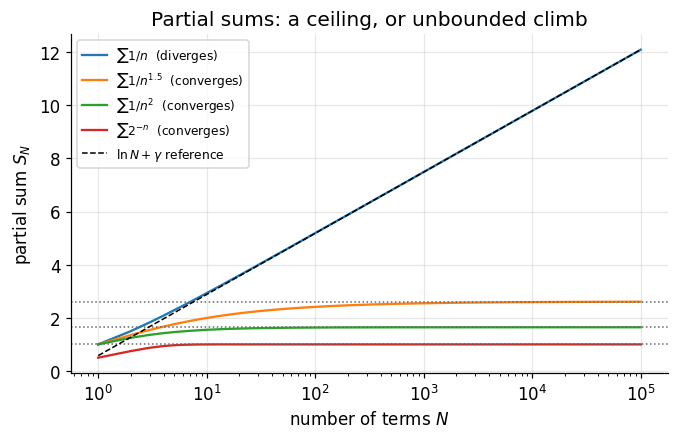

S_N for 1/n at N = 10^5 : 12.090146129863335
ln N + gamma at N = 10^5 : 12.09014112987023
S_N for 1/n^2 at N = 10^5: 1.6449240668982423
pi^2/6                   : 1.6449340668482264


In [2]:
# Figure 1: the staircase picture. Which partial-sum sequences hit a ceiling?
N = 10**5
n = np.arange(1, N + 1, dtype=np.float64)

series = {
    r"$\sum 1/n$  (diverges)":        1.0 / n,
    r"$\sum 1/n^{1.5}$  (converges)": 1.0 / n**1.5,
    r"$\sum 1/n^{2}$  (converges)":   1.0 / n**2,
    r"$\sum 2^{-n}$  (converges)":    0.5 ** n,
}
limits = {
    r"$\sum 1/n^{1.5}$  (converges)": float(special.zeta(1.5, 1)),
    r"$\sum 1/n^{2}$  (converges)":   math.pi**2 / 6,
    r"$\sum 2^{-n}$  (converges)":    1.0,
}

fig, ax = plt.subplots()
for label, a in series.items():
    ax.plot(n, np.cumsum(a), label=label)
for label, L in limits.items():
    ax.axhline(L, linestyle=":", linewidth=1, color="0.4")
ax.plot(n, np.log(n) + 0.5772156649, "--", color="k", linewidth=1,
        label=r"$\ln N + \gamma$ reference")
ax.set_xscale("log")
ax.set_xlabel("number of terms $N$")
ax.set_ylabel("partial sum $S_N$")
ax.set_title("Partial sums: a ceiling, or unbounded climb")
ax.legend(fontsize=8, loc="upper left")
plt.show()

print("S_N for 1/n at N = 10^5 :", np.cumsum(series[r"$\sum 1/n$  (diverges)"])[-1])
print("ln N + gamma at N = 10^5 :", math.log(N) + 0.5772156649)
print("S_N for 1/n^2 at N = 10^5:", np.cumsum(series[r"$\sum 1/n^{2}$  (converges)"])[-1])
print("pi^2/6                   :", math.pi**2 / 6)

The harmonic staircase tracks $\ln N + \gamma$ — a straight line on a log axis, so it never
levels off. The other three flatten onto their dotted ceilings. Note how little the term size
alone tells you: $1/n$ and $1/n^{1.5}$ both go to zero, and their behaviour is opposite.

## 3. Definitions

### Definition 3.1 (Completeness axiom)

Every non-empty $E \subseteq \mathbb{R}$ that is bounded above has a least upper bound
$\sup E \in \mathbb{R}$; every non-empty $E$ bounded below has a greatest lower bound
$\inf E \in \mathbb{R}$. This is an axiom of $\mathbb{R}$, not a theorem; $\mathbb{Q}$ fails
it, since $\{q \in \mathbb{Q} : q^2 \lt 2\}$ has no rational least upper bound.

### Definition 3.2 (Convergence of a sequence)

A sequence is a function $a : \mathbb{N} \to \mathbb{R}$, written $(a_n)$. It **converges**
to $L \in \mathbb{R}$, written $a_n \to L$, if

$$
\forall \varepsilon \gt 0 \ \ \exists N \in \mathbb{N} \ \ \forall n \gt N : \quad \lvert a_n - L \rvert \lt \varepsilon .
$$

A sequence that converges to no $L$ **diverges**. Limits are unique: if $a_n \to L$ and
$a_n \to L'$ then $\lvert L - L' \rvert \lt 2\varepsilon$ for every $\varepsilon \gt 0$, so $L = L'$.

### Definition 3.3 (Monotone and bounded)

$(a_n)$ is **non-decreasing** if $a_{n+1} \ge a_n$ for all $n$, **non-increasing** if
$a_{n+1} \le a_n$ for all $n$, and **monotone** if it is one of the two. It is **bounded
above** if some $M$ satisfies $a_n \le M$ for all $n$, **bounded below** symmetrically, and
**bounded** if both.

### Definition 3.4 (Limit superior and limit inferior)

For a bounded sequence $(a_n)$ put $b_n = \sup_{k \ge n} a_k$ and $c_n = \inf_{k \ge n} a_k$.
Then $(b_n)$ is non-increasing and $(c_n)$ is non-decreasing, and both are bounded, so both
converge by Theorem 4.1. Define

$$
\limsup_{n\to\infty} a_n := \lim_{n\to\infty}\ \sup_{k \ge n} a_k, \qquad
\liminf_{n\to\infty} a_n := \lim_{n\to\infty}\ \inf_{k \ge n} a_k .
$$

Always $\liminf a_n \le \limsup a_n$, and $\lim a_n$ exists exactly when the two are equal,
in which case all three agree. Unlike $\lim$, the $\limsup$ of a bounded sequence always
exists, which is why the Root Test is stated with it.

### Definition 3.5 (Cauchy sequence)

$(a_n)$ is **Cauchy** if

$$
\forall \varepsilon \gt 0 \ \ \exists N \in \mathbb{N} \ \ \forall m, n \gt N : \quad \lvert a_n - a_m \rvert \lt \varepsilon .
$$

The definition mentions no limit, so it can be checked from the terms alone.

### Definition 3.6 (Series, partial sums, tail)

Given $(a_n)_{n \ge 1}$, its **partial sums** are $S_N = \sum_{k=1}^{N} a_k$. The **series**
$\sum_{k=1}^{\infty} a_k$ **converges to $S$** if $S_N \to S$, and diverges otherwise. When it
converges, the **tail** (or remainder) is $R_N = S - S_N = \sum_{k \gt N} a_k$.

### Definition 3.7 (Absolute and conditional convergence)

$\sum a_n$ **converges absolutely** if $\sum \lvert a_n \rvert$ converges. It **converges
conditionally** if $\sum a_n$ converges while $\sum \lvert a_n \rvert$ diverges.

### Definition 3.8 (Rearrangement)

A **rearrangement** of $\sum a_n$ is the series $\sum a_{\sigma(n)}$ for a bijection
$\sigma : \mathbb{N} \to \mathbb{N}$. Rearranging changes no term, only the order in which the
partial sums accumulate them.

## 4. Main Results

### Theorem 4.1 (Monotone Convergence Theorem)

If $(a_n)$ is non-decreasing and bounded above, then $(a_n)$ converges and
$\lim_n a_n = \sup\{a_n : n \in \mathbb{N}\}$. Symmetrically, non-increasing and bounded below
gives convergence to the infimum.

- *Monotonicity* is needed to rule out oscillation: $a_n = (-1)^n$ is bounded and does not converge.
- *Boundedness* is needed to rule out escape: $a_n = n$ is non-decreasing and does not converge.

Proved in Proof 5.1.

### Theorem 4.2 (Bolzano-Weierstrass)

Every bounded sequence in $\mathbb{R}$ has a convergent subsequence.

- *Boundedness* is needed: $a_n = n$ has no convergent subsequence.

Proved in Proof 5.2.

### Theorem 4.3 (Cauchy criterion)

A sequence of real numbers converges if and only if it is Cauchy.

- The *"only if"* direction holds in any metric space; the *"if"* direction is precisely
  completeness of $\mathbb{R}$ and fails in $\mathbb{Q}$, where the decimal truncations of
  $\sqrt{2}$ are Cauchy with no rational limit.

Proved in Proof 5.3.

### Theorem 4.4 (Series baseline: $n$-th term test and the geometric series)

1. If $\sum_{n \ge 1} a_n$ converges then $a_n \to 0$. Equivalently, if $a_n \not\to 0$ the
   series diverges. The converse is false, so this is only a filter.
2. For $a \ne 0$ and $r \in \mathbb{R}$, $\sum_{k \ge 0} a r^k$ converges if and only if
   $\lvert r \rvert \lt 1$, and then

$$
\boxed{\ \sum_{k=0}^{\infty} a r^{k} = \frac{a}{1 - r}, \qquad \lvert r \rvert \lt 1\ }
$$

**Interpretation.** The whole infinite tail costs only the factor $1/(1-r)$ relative to the
first term: geometric decay is so fast that the sum is dominated by its first few terms.
Consequently $1/(1-r)$ blows up as $r \uparrow 1$, which is exactly why a
reinforcement-learning return with discount $\gamma$ has effective horizon $1/(1-\gamma)$ and
why a Neumann expansion converges slowly when the spectral radius is near $1$. The hypothesis
$\lvert r \rvert \lt 1$ is needed because for $\lvert r \rvert \ge 1$ the terms do not tend to
zero, so part 1 already forbids convergence.

Proved in Proof 5.4.

### Theorem 4.5 (Integral test, with remainder bounds, and the $p$-series criterion)

Let $f : [1, \infty) \to \mathbb{R}$ be continuous, positive and non-increasing, and set
$a_n = f(n)$. Then $\sum_{n \ge 1} a_n$ converges if and only if $\int_1^{\infty} f(x)\,dx$
converges, and in the convergent case the tail obeys

$$
\boxed{\ \int_{N+1}^{\infty} f(x)\,dx \ \le\ R_N \ \le\ \int_{N}^{\infty} f(x)\,dx\ }
$$

**Interpretation.** The test does not merely answer yes or no: it brackets the discarded tail
between two computable integrals whose ratio tends to $1$, so truncating at $N$ terms comes
with a two-sided error bar. Taking $f(x) = x^{-p}$ gives $R_N \asymp N^{1-p}/(p-1)$, which is
how you choose $N$ for a prescribed accuracy instead of guessing.

- *Positivity* and *monotonicity* are needed so that $f(k+1) \le f(x) \le f(k)$ on $[k, k+1]$;
  without monotonicity a spiky $f$ can have a small integral and a large sum.
- *Continuity* is needed only so that the Riemann integrals exist.

Specialising to $f(x) = x^{-p}$:

$$
\boxed{\ \sum_{n=1}^{\infty} \frac{1}{n^{p}} \ \text{converges} \iff p \gt 1\ }
$$

**Interpretation.** $p = 1$ is the exact frontier: the harmonic series is the slowest
divergence in the polynomial family, and every polynomial-decay question reduces to comparing
against it. The frontier is what makes $\sum \alpha_t = \infty$ with $\sum \alpha_t^2 \lt \infty$
possible at all, since squaring $t^{-p}$ moves the exponent from $p \le 1$ to $2p \gt 1$.

Proved in Proof 5.5.

### Theorem 4.6 (Comparison and limit comparison)

Let $a_n \gt 0$ and $b_n \gt 0$ for all $n \ge N_0$.

1. **Direct comparison.** If $a_n \le b_n$ for $n \ge N_0$ and $\sum b_n$ converges then
   $\sum a_n$ converges; if $a_n \ge b_n$ for $n \ge N_0$ and $\sum b_n$ diverges then
   $\sum a_n$ diverges.
2. **Limit comparison.** Suppose $a_n / b_n \to L$. If $0 \lt L \lt \infty$ the two series
   converge or diverge together; if $L = 0$ and $\sum b_n$ converges then $\sum a_n$
   converges; if $L = \infty$ and $\sum b_n$ diverges then $\sum a_n$ diverges.

- *Positivity* is needed because the argument runs through the Monotone Convergence Theorem
  applied to partial sums; for signed terms the partial sums are not monotone and the
  conclusion fails.
- The inequality is only needed *eventually*, since changing finitely many terms shifts the
  sum but cannot change convergence.

Proved in Proof 5.6.

### Theorem 4.7 (Ratio test and root test)

Let $\sum a_n$ have $a_n \ne 0$ eventually.

1. **Ratio (d'Alembert).** If $L = \lim_n \lvert a_{n+1}/a_n \rvert$ exists, then $L \lt 1$
   gives absolute convergence, $L \gt 1$ gives divergence, and $L = 1$ decides nothing.
2. **Root (Cauchy).** With $L = \limsup_n \lvert a_n \rvert^{1/n}$, the same trichotomy holds.

- Both tests work by *dominating the tail with a geometric series*, so a strict gap
  $L \lt 1$ is essential; at $L = 1$ no geometric bound exists, and $\sum 1/n$ (divergent)
  and $\sum 1/n^2$ (convergent) both sit there.
- The root test is strictly stronger: whenever the ratio limit exists the root limit exists
  and equals it, but the root test still applies when $\lvert a_{n+1}/a_n \rvert$ oscillates,
  because $\limsup$ always exists for a bounded sequence.

Proved in Proof 5.7.

### Theorem 4.8 (Leibniz criterion with remainder bound)

If $b_n \gt 0$, $(b_n)$ is non-increasing and $b_n \to 0$, then
$\sum_{n \ge 1} (-1)^{n-1} b_n$ converges to some $S$, the even partial sums increase to $S$,
the odd ones decrease to $S$, and

$$
\boxed{\ \lvert R_N \rvert = \lvert S - S_N \rvert \ \le\ b_{N+1}\ }
$$

**Interpretation.** The first neglected term is itself the error bound, and the true value is
bracketed by any two consecutive partial sums — the cheapest rigorous error estimate in all of
series numerics. It costs nothing to compute, which is why alternating expansions are
preferred for hand-checkable truncation.

- *Monotonicity* is essential, not cosmetic: dropping it while keeping $b_n \to 0$ permits
  divergence, as the counterexample in Section 7 shows.
- $b_n \to 0$ is forced by Theorem 4.4.

Proved in Proof 5.8.

### Theorem 4.9 (Absolute convergence, and the Riemann rearrangement theorem)

1. If $\sum \lvert a_n \rvert$ converges then $\sum a_n$ converges, and every rearrangement
   converges to the same sum.
2. If $\sum a_n$ converges conditionally then for every $M \in \mathbb{R}$ there is a
   rearrangement $\sigma$ with $\sum_n a_{\sigma(n)} = M$; there are also rearrangements
   diverging to $+\infty$ and to $-\infty$.

- Part 2 needs *conditional* convergence exactly because it needs both the positive part and
  the negative part to have infinite mass; absolute convergence makes both finite and part 1
  applies instead.

Proved in Proof 5.9 (part 1 and part 2 for finite $M$; the $\pm\infty$ case is the same
construction with a target sequence tending to $\pm\infty$).

### Theorem 4.10 (Raabe's test)

Let $a_n \gt 0$ and suppose $R = \lim_{n\to\infty} n\left(1 - \dfrac{a_{n+1}}{a_n}\right)$
exists in $[-\infty, \infty]$. Then

$$
\boxed{\ R \gt 1 \implies \sum a_n \ \text{converges}, \qquad R \lt 1 \implies \sum a_n \ \text{diverges}\ }
$$

**Interpretation.** $R$ reads off the *effective $p$-exponent* hidden in the term ratio: for
$a_n = n^{-p}$ one gets $R = p$ exactly, so Raabe's test is the $p$-series criterion promoted
to a limit of ratios. It is the natural next instrument when the ratio test returns $L = 1$,
because $L = 1$ says only that $a_{n+1}/a_n = 1 - O(1/n)$ and $R$ measures the constant in
that $O(1/n)$.

- *Positivity* is needed for the same reason as in Theorem 4.6.
- $R = 1$ is genuinely undecided (compare $\sum 1/(n\ln^2 n)$, convergent, with
  $\sum 1/(n \ln n)$, divergent; both give $R = 1$).

Proved in Proof 5.10, directly from Theorem 4.1 and Theorem 4.6 — no auxiliary test is assumed.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Let $E = \{a_n : n \in \mathbb{N}\}$, non-empty and bounded above, so by Definition 3.1
$L = \sup E$ exists. Fix $\varepsilon \gt 0$. Since $L - \varepsilon$ is not an upper bound of
$E$, there is $N$ with $a_N \gt L - \varepsilon$. Monotonicity gives, for every $n \ge N$,

$$
L - \varepsilon \lt a_N \le a_n \le L \lt L + \varepsilon ,
$$

so $\lvert a_n - L \rvert \lt \varepsilon$. As $\varepsilon$ was arbitrary, $a_n \to L$. The
non-increasing case follows by applying this to $(-a_n)$. $\blacksquare$

### Proof 5.2 (of Theorem 4.2)

All terms lie in a closed interval $I_0 = [c, d]$. Bisect $I_0$; at least one closed half
contains $a_n$ for infinitely many indices $n$, since a union of two sets cannot be infinite
if both are finite. Call that half $I_1$ and choose $n_1$ with $a_{n_1} \in I_1$. Repeat:
having chosen $I_k$ containing infinitely many terms and $n_k$, bisect $I_k$, let $I_{k+1}$ be
a half containing infinitely many terms, and pick $n_{k+1} \gt n_k$ with
$a_{n_{k+1}} \in I_{k+1}$ — possible precisely because infinitely many indices qualify.

The intervals are nested with $\lvert I_k \rvert = (d-c)2^{-k}$. Write $I_k = [u_k, v_k]$.
Then $(u_k)$ is non-decreasing and bounded above by $d$, so by Theorem 4.1 it converges to
some $L$; since $v_k - u_k \to 0$, also $v_k \to L$ and $L \in I_k$ for every $k$. Finally
$\lvert a_{n_k} - L \rvert \le \lvert I_k \rvert \to 0$, so $(a_{n_k})$ converges to $L$. $\blacksquare$

### Proof 5.3 (of Theorem 4.3)

$(\Rightarrow)$ Let $a_n \to L$ and $\varepsilon \gt 0$. Choose $N$ with
$\lvert a_n - L \rvert \lt \varepsilon/2$ for $n \gt N$. For $m, n \gt N$ the triangle
inequality gives
$\lvert a_n - a_m \rvert \le \lvert a_n - L \rvert + \lvert L - a_m \rvert \lt \varepsilon$.

$(\Leftarrow)$ Let $(a_n)$ be Cauchy. Taking $\varepsilon = 1$ gives $N_1$ with
$\lvert a_n - a_{N_1 + 1} \rvert \lt 1$ for $n \gt N_1$, hence

$$
\lvert a_n \rvert \le \max\{\lvert a_1 \rvert, \dots, \lvert a_{N_1} \rvert, \lvert a_{N_1+1}\rvert + 1\}
$$

for every $n$: the sequence is bounded. By Theorem 4.2 some subsequence $a_{n_k} \to L$. Fix
$\varepsilon \gt 0$ and choose $N$ with $\lvert a_n - a_m \rvert \lt \varepsilon/2$ for
$m, n \gt N$; choose $k$ with $n_k \gt N$ and $\lvert a_{n_k} - L \rvert \lt \varepsilon/2$.
Then for every $n \gt N$,

$$
\lvert a_n - L \rvert \le \lvert a_n - a_{n_k} \rvert + \lvert a_{n_k} - L \rvert \lt \varepsilon .
$$

So $a_n \to L$. $\blacksquare$

### Proof 5.4 (of Theorem 4.4)

**Part 1.** If $S_N \to S$ then $S_{N-1} \to S$ as well, and $a_N = S_N - S_{N-1}$, so
$a_N \to S - S = 0$ by the algebra of limits.

**Part 2.** For $r \ne 1$ put $T_N = \sum_{k=0}^{N-1} a r^k$. Then
$T_N - r T_N = a - a r^{N}$, so $T_N = a(1 - r^{N})/(1 - r)$. If $\lvert r \rvert \lt 1$ then
$r^N \to 0$ — because $\lvert r \rvert^N$ is non-increasing and bounded below, hence
convergent to some $\ell \ge 0$ by Theorem 4.1, and $\ell = \lvert r \rvert \ell$ forces
$\ell = 0$ — giving $T_N \to a/(1-r)$. If $\lvert r \rvert \ge 1$ then
$\lvert a r^k \rvert \ge \lvert a \rvert \gt 0$ does not tend to $0$, so part 1 gives
divergence; for $r = 1$ directly $T_N = aN$, unbounded. $\blacksquare$

### Proof 5.5 (of Theorem 4.5)

Because $f$ is non-increasing, $f(k+1) \le f(x) \le f(k)$ for $x \in [k, k+1]$, and
integrating over that unit interval,

$$
a_{k+1} \ \le\ \int_k^{k+1} f(x)\,dx \ \le\ a_k .
$$

Summing $k = 1, \dots, N-1$ gives $\sum_{k=2}^{N} a_k \le \int_1^{N} f \le \sum_{k=1}^{N-1} a_k$.

If $\int_1^{\infty} f \lt \infty$, then $S_N \le a_1 + \int_1^{\infty} f$ for every $N$, so the
non-decreasing sequence $(S_N)$ is bounded above and converges by Theorem 4.1. If
$\int_1^{\infty} f = \infty$, then $S_N \ge \int_1^{N+1} f \to \infty$, so $(S_N)$ is unbounded
and diverges.

For the remainder, sum $a_{k+1} \le \int_k^{k+1} f \le a_k$ over $k \ge N$:
$\sum_{k \ge N+1} a_k \le \int_N^{\infty} f$, which is the upper bound; and over $k \ge N+1$:
$\int_{N+1}^{\infty} f \le \sum_{k \ge N+1} a_k$, the lower bound.

For $f(x) = x^{-p}$ with $p \gt 0$ the hypotheses hold. If $p = 1$,
$\int_1^{M} x^{-1}dx = \ln M \to \infty$. If $p \ne 1$,
$\int_1^{M} x^{-p}dx = (M^{1-p} - 1)/(1-p)$, which tends to $1/(p-1)$ when $p \gt 1$ and to
$\infty$ when $p \lt 1$. For $p \le 0$ the terms $n^{-p}$ do not tend to $0$, so Theorem 4.4
gives divergence. Hence convergence holds exactly for $p \gt 1$. $\blacksquare$

### Proof 5.6 (of Theorem 4.6)

**Direct comparison.** Discard the first $N_0 - 1$ terms, which affects neither series'
convergence. If $a_n \le b_n$ and $\sum b_n = B \lt \infty$, then the partial sums of
$\sum a_n$ satisfy $S_N \le B$; they are non-decreasing because $a_n \gt 0$, so Theorem 4.1
applies. If $a_n \ge b_n$ and the partial sums of $\sum b_n$ are unbounded, those of
$\sum a_n$ dominate them and are unbounded too.

**Limit comparison, $0 \lt L \lt \infty$.** Take $\varepsilon = L/2$. There is $N$ with
$\lvert a_n/b_n - L\rvert \lt L/2$ for $n \ge N$, i.e.

$$
\tfrac{L}{2} b_n \ \lt\ a_n \ \lt\ \tfrac{3L}{2} b_n \qquad (n \ge N).
$$

The right inequality plus direct comparison transfers convergence of $\sum b_n$ to
$\sum a_n$; the left inequality plus direct comparison transfers divergence.

**$L = 0$.** There is $N$ with $a_n \lt b_n$ for $n \ge N$; apply direct comparison.
**$L = \infty$.** There is $N$ with $a_n \gt b_n$ for $n \ge N$; apply direct comparison. $\blacksquare$

### Proof 5.7 (of Theorem 4.7)

**Ratio, $L \lt 1$.** Pick $r$ with $L \lt r \lt 1$ and set $\varepsilon = r - L \gt 0$. There
is $N$ with $\lvert a_{n+1}/a_n \rvert \lt r$ for all $n \ge N$, hence by induction
$\lvert a_{N+k} \rvert \lt r^{k} \lvert a_N \rvert$. Since $\sum_k \lvert a_N \rvert r^{k}$
converges by Theorem 4.4, direct comparison gives convergence of $\sum \lvert a_n \rvert$.

**Ratio, $L \gt 1$.** There is $N$ with $\lvert a_{n+1} \rvert \gt \lvert a_n \rvert$ for
$n \ge N$, so $\lvert a_n \rvert \ge \lvert a_N \rvert \gt 0$ and $a_n \not\to 0$; Theorem 4.4
gives divergence.

**Root, $L \lt 1$.** Pick $r$ with $L \lt r \lt 1$. Since
$\sup_{k \ge n}\lvert a_k \rvert^{1/k} \to L \lt r$, there is $N$ with
$\lvert a_n \rvert^{1/n} \lt r$, i.e. $\lvert a_n \rvert \lt r^{n}$, for all $n \ge N$.
Compare with the convergent $\sum r^{n}$.

**Root, $L \gt 1$.** Then $\lvert a_n \rvert^{1/n} \gt 1$ for infinitely many $n$, so
$\lvert a_n \rvert \gt 1$ infinitely often and $a_n \not\to 0$; Theorem 4.4 gives divergence.

**Strength.** If $\lim \lvert a_{n+1}/a_n \rvert = L$ then for any $r \gt L$ eventually
$\lvert a_n \rvert \le C r^{n}$, so $\limsup \lvert a_n \rvert^{1/n} \le r$; letting
$r \downarrow L$ gives $\limsup \lvert a_n\rvert^{1/n} \le L$, and the symmetric argument with
$r \lt L$ gives $\liminf \lvert a_n \rvert^{1/n} \ge L$. Hence the root limit exists and
equals $L$ whenever the ratio limit does; the converse fails, as Example 6.6 shows. $\blacksquare$

### Proof 5.8 (of Theorem 4.8)

Group the even partial sums as
$S_{2n} = (b_1 - b_2) + \cdots + (b_{2n-1} - b_{2n})$. Every bracket is $\ge 0$ by
monotonicity, so $(S_{2n})$ is non-decreasing. Regrouping the other way,
$S_{2n} = b_1 - (b_2 - b_3) - \cdots - (b_{2n-2} - b_{2n-1}) - b_{2n} \le b_1$, so it is
bounded above. By Theorem 4.1, $S_{2n} \to S$ for some $S$. Since
$S_{2n+1} = S_{2n} + b_{2n+1}$ and $b_n \to 0$, also $S_{2n+1} \to S$; as both subsequences of
$(S_N)$ converge to $S$ and together exhaust the indices, $S_N \to S$.

Moreover $(S_{2n})$ increases to $S$ and $(S_{2n+1})$ decreases to $S$, so $S$ lies between
$S_N$ and $S_{N+1}$ for every $N$. Therefore
$\lvert S - S_N \rvert \le \lvert S_{N+1} - S_N \rvert = b_{N+1}$. $\blacksquare$

### Proof 5.9 (of Theorem 4.9)

**Part 1.** From $0 \le a_n + \lvert a_n \rvert \le 2\lvert a_n \rvert$ and direct comparison,
$\sum (a_n + \lvert a_n \rvert)$ converges. Then
$\sum a_n = \sum(a_n + \lvert a_n \rvert) - \sum \lvert a_n \rvert$ converges as a difference
of convergent series. For rearrangement invariance, let $\sigma$ be a bijection, $\varepsilon \gt 0$,
and choose $N$ with $\sum_{k \gt N} \lvert a_k \rvert \lt \varepsilon$. Choose $M$ so large
that $\{1,\dots,N\} \subseteq \sigma(\{1,\dots,M\})$. For $m \ge M$ the difference
$\sum_{k=1}^{m} a_{\sigma(k)} - \sum_{k=1}^{N} a_k$ involves only indices $\gt N$, so it is at
most $\varepsilon$ in absolute value; letting $m \to \infty$ and then $\varepsilon \to 0$ gives
equality of the two sums.

**Part 2.** Write $p_n = \max(a_n, 0)$ and $q_n = \max(-a_n, 0)$, so $a_n = p_n - q_n$ and
$\lvert a_n \rvert = p_n + q_n$. If both $\sum p_n$ and $\sum q_n$ converged, then
$\sum \lvert a_n \rvert$ would converge, contradicting conditionality; if exactly one
converged, then $\sum a_n = \sum p_n - \sum q_n$ would diverge to $\mp\infty$, contradicting
convergence. Hence $\sum p_n = \sum q_n = \infty$. Also $a_n \to 0$ by Theorem 4.4, so
$p_n \to 0$ and $q_n \to 0$.

List the strictly positive terms of $(a_n)$ in their original order as $P_1, P_2, \dots$ and
the absolute values of the strictly negative terms as $Q_1, Q_2, \dots$ (zero terms may be
inserted anywhere later without affecting anything). Fix $M \in \mathbb{R}$ and build the
rearrangement greedily: take $P_1, \dots, P_{m_1}$ where $m_1$ is the smallest index making the
running sum exceed $M$ — possible because $\sum P_k = \infty$; then append
$Q_1, \dots, Q_{n_1}$ with signs, $n_1$ smallest making the running sum fall below $M$ —
possible because $\sum Q_k = \infty$; then continue with $P_{m_1+1}, \dots, P_{m_2}$ until the
sum again exceeds $M$, and so on. Each $m_j$ and $n_j$ is finite and strictly increasing, so
every term is used exactly once and the construction is a bijection.

By minimality of each $m_j$, at the moment the running sum first exceeds $M$ it exceeds it by
at most the last term added, $P_{m_j}$; likewise at each downward crossing it falls below $M$
by at most $Q_{n_j}$. Between two consecutive crossings the running sum is monotone, so it
stays within $\max(P_{m_j}, Q_{n_j})$ of $M$. Since $P_k \to 0$ and $Q_k \to 0$, these
deviations tend to $0$, so the rearranged partial sums converge to $M$. $\blacksquare$

### Proof 5.10 (of Theorem 4.10)

**Case $R \gt 1$.** Choose $r$ with $1 \lt r \lt R$. There is $N \ge 2$ such that for all
$n \ge N$,

$$
n\left(1 - \frac{a_{n+1}}{a_n}\right) \gt r
\quad\Longleftrightarrow\quad
n\,a_{n+1} \lt (n - r)\,a_n .
$$

Put $t_n = (n-1)a_n \ge 0$. Then $t_{n+1} = n a_{n+1} \lt (n-r)a_n = t_n - (r-1)a_n$, so

$$
(r-1)\,a_n \lt t_n - t_{n+1} \qquad (n \ge N).
$$

Summing $n = N, \dots, M$ telescopes the right side:
$(r-1)\sum_{n=N}^{M} a_n \lt t_N - t_{M+1} \le t_N$. Since $r \gt 1$, the partial sums of
$\sum a_n$ are bounded above, and they are non-decreasing because $a_n \gt 0$; Theorem 4.1
gives convergence.

**Case $R \lt 1$.** There is $N$ with $n(1 - a_{n+1}/a_n) \lt 1$ for all $n \ge N$, i.e.
$n\,a_{n+1} \gt (n-1)a_n$, i.e. $t_{n+1} \gt t_n$ with $t_n = (n-1)a_n$ as above. So
$(t_n)_{n \gt N}$ is increasing, and with $c := t_{N+1} = N a_{N+1} \gt 0$ we get
$a_n = t_n/(n-1) \ge c/(n-1)$ for all $n \gt N$. Since $\sum_n 1/(n-1)$ diverges by
Theorem 4.5, direct comparison (Theorem 4.6) gives divergence. $\blacksquare$

*Remark.* For $a_n = n^{-p}$ one has
$a_{n+1}/a_n = (1 + 1/n)^{-p} = 1 - p/n + O(n^{-2})$, hence $R = p$: Raabe's parameter is
literally the $p$-series exponent, which is why Theorem 4.10 resolves exactly the cases
Theorem 4.7 cannot.

## 6. Worked Examples

Each example is computed by hand on a deliberately small object; the code cells that follow
recompute the same numbers and assert agreement.

### Example 6.1 (Theorem 4.1: a recursion with a fixed point)

Let $x_1 = 1$ and $x_{n+1} = \sqrt{2 + x_n}$.
*Bounded:* $x_1 = 1 \lt 2$, and $x_n \lt 2 \Rightarrow x_{n+1} = \sqrt{2 + x_n} \lt \sqrt{4} = 2$.
*Monotone:*

$$
x_{n+1} - x_n = \frac{2 + x_n - x_n^2}{\sqrt{2 + x_n} + x_n} = \frac{(2 - x_n)(1 + x_n)}{\sqrt{2 + x_n} + x_n} \gt 0
\quad\text{for } 1 \le x_n \lt 2 .
$$

By Theorem 4.1 the limit $L$ exists; passing to the limit in $x_{n+1}^2 = 2 + x_n$ gives
$L^2 - L - 2 = 0$, so $L \in \{2, -1\}$, and $L \ge 1$ forces $L = 2$. First terms:
$x_1 = 1$, $x_2 = \sqrt{3} = 1.7320508$, $x_3 = \sqrt{3.7320508} = 1.9318517$.

### Example 6.2 (Theorems 4.2 and 4.3: bounded but not convergent)

$a_n = \cos n$ is bounded in $[-1, 1]$ and does not converge (the integers are dense modulo
$2\pi$, so values accumulate throughout $[-1,1]$). Theorem 4.2 nevertheless guarantees a
convergent subsequence, and one can be exhibited by keeping only indices with
$\lvert \cos n - 1 \rvert \lt \delta$ for a shrinking $\delta$. Since $(\cos n)$ is not
convergent, Theorem 4.3 says it cannot be Cauchy — and indeed $\lvert a_n - a_m \rvert$ gets
close to $2$ for arbitrarily large $m, n$.

### Example 6.3 (Theorem 4.4: geometric series and the term test)

$\sum_{k \ge 0} 3 \cdot (1/4)^k = 3 / (1 - 1/4) = 4$. By hand,
$T_4 = 3 + 0.75 + 0.1875 + 0.046875 = 3.984375$, and the exact tail is
$4 - T_4 = 3\,(1/4)^4/(1 - 1/4) = 3/256 \cdot 4/3 = 0.015625$.
By contrast $\sum_{n\ge1} n/(n+1)$ diverges: $a_n = n/(n+1) \to 1 \ne 0$.

### Example 6.4 (Theorem 4.5: bracketing the tail of $\sum 1/n^2$)

Take $f(x) = x^{-2}$, $N = 4$. Then $\int_N^{\infty} x^{-2}dx = 1/4 = 0.25$ and
$\int_{N+1}^{\infty} x^{-2}dx = 1/5 = 0.2$, so $0.2 \le R_4 \le 0.25$. By hand
$S_4 = 1 + 0.25 + 0.\overline{1} + 0.0625 = 1.4236111$, and the true sum is
$\pi^2/6 = 1.6449341$, giving $R_4 = 0.2213230$ — inside the bracket, as Theorem 4.5 requires.

### Example 6.5 (Theorem 4.6: limit comparison on a rational term)

For $a_n = (n^2 + 4)/(n^4 - n^2 + 1)$ take $b_n = 1/n^2$. Then

$$
\frac{a_n}{b_n} = \frac{n^4 + 4n^2}{n^4 - n^2 + 1} = \frac{1 + 4n^{-2}}{1 - n^{-2} + n^{-4}} \longrightarrow 1 \in (0, \infty),
$$

so $\sum a_n$ converges together with $\sum 1/n^2$. At $n = 3$: $a_3 = 13/73 = 0.1780822$ and
$b_3 = 1/9 = 0.\overline{1}$, ratio $1.6027$ — still far from $1$, which is why the *limit*,
not any single ratio, is what the test uses.

### Example 6.6 (Theorem 4.7: where the ratio test cannot go)

Let $a_n = 2^{-n}$ for even $n$ and $a_n = 2^{-n+2}$ for odd $n$. Then
$\lvert a_{n+1}/a_n \rvert$ alternates between $2$ and $1/8$, so the ratio limit does not
exist; but $\lvert a_n \rvert^{1/n} \le (4 \cdot 2^{-n})^{1/n} = 4^{1/n}/2 \to 1/2$, so
$\limsup \lvert a_n\rvert^{1/n} = 1/2 \lt 1$ and the root test gives absolute convergence.
Summing exactly: odd terms $\sum_{k\ge0} 2^{-(2k+1)+2} = 2\sum_{k\ge0}4^{-k} = 8/3$, even
terms $\sum_{k\ge1} 2^{-2k} = 1/3$, total $3$.

### Example 6.7 (Theorem 4.8: Leibniz bound on $\sum(-1)^{n-1}n^{-3}$)

$S_1 = 1$, $S_2 = 0.875$, $S_3 = 0.9120370$, $S_4 = 0.8964120$. The limit is
$\eta(3) = \tfrac{3}{4}\zeta(3) = 0.9015427$. Theorem 4.8 predicts
$\lvert S - S_4 \rvert \le b_5 = 5^{-3} = 0.008$; the actual error is $0.0051307$. To force
error $\lt 10^{-4}$ it suffices that $b_{N+1} = (N+1)^{-3} \lt 10^{-4}$, i.e.
$N + 1 \gt 10^{4/3} = 21.544$, so $N = 21$.

### Example 6.8 (Theorem 4.9: rearranging the alternating harmonic series)

$S = \sum (-1)^{n-1}/n = \ln 2$. Interleaving two positives per negative gives
$\left(1 + \tfrac13 - \tfrac12\right) + \left(\tfrac15 + \tfrac17 - \tfrac14\right) + \cdots$,
which is $S + \tfrac12 S = \tfrac32 \ln 2 = 1.0397208$: the terms are unchanged, the sum is
not. The first block alone is $1 + 0.\overline{3} - 0.5 = 0.8\overline{3}$.

### Example 6.9 (Theorem 4.10: a double-factorial series where the ratio test fails)

Let $a_n = \dfrac{(2n-1)!!}{(2n)!!\,(2n+1)}$. Then

$$
\frac{a_{n+1}}{a_n} = \frac{2n+1}{2n+2}\cdot\frac{2n+1}{2n+3} = \frac{(2n+1)^2}{(2n+2)(2n+3)} \longrightarrow 1,
$$

so Theorem 4.7 is silent. But

$$
n\left(1 - \frac{a_{n+1}}{a_n}\right) = n \cdot \frac{6n + 5}{4n^2 + 10n + 6} \longrightarrow \frac{6}{4} = \frac{3}{2} \gt 1 ,
$$

so Theorem 4.10 gives convergence. At $n = 1$: $a_1 = 1/(2\cdot3) = 0.1\overline{6}$ and
$a_2/a_1 = 9/20 \cdot \dots = 9/(4 \cdot 5) = 0.45$. The sum is $\pi/2 - 1 = 0.5707963$,
because $\arcsin(1) = 1 + \sum_{n \ge 1} a_n$.

The cell below recomputes every number quoted in Examples 6.1, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8
and 6.9 and asserts agreement with the hand computation. Residuals for the exact identities
(geometric sum, root-test example, Raabe example) are printed so their size can be judged.

In [3]:
# (a) identity residuals: every closed form quoted by hand, recomputed and asserted.

# Example 6.1 -- recursion x_{n+1} = sqrt(2 + x_n)
x = 1.0
first = [x]
for _ in range(3):
    x = math.sqrt(2.0 + x)
    first.append(x)
for _ in range(200):
    x = math.sqrt(2.0 + x)
print(f"6.1 x_1..x_4      : {np.array(first)}")
print(f"6.1 limit         : {x:.15f}   residual vs 2: {abs(x - 2.0):.3e}")
assert abs(first[1] - math.sqrt(3.0)) < 1e-15 and abs(x - 2.0) < 1e-12

# Example 6.3 -- geometric series, boxed identity of Theorem 4.4
a, r = 3.0, 0.25
K = 400
geo_partial = np.sum(a * r ** np.arange(K))
res_geo = abs(geo_partial - a / (1.0 - r))
T4 = a * (1 - r**4) / (1 - r)
print(f"6.3 sum 3(1/4)^k  : {geo_partial:.15f}   residual vs a/(1-r): {res_geo:.3e}")
print(f"6.3 T_4           : {T4}   tail 4 - T_4: {4.0 - T4}")
assert res_geo < 1e-14 and abs(T4 - 3.984375) < 1e-15

# Example 6.4 -- integral-test bracket for sum 1/n^2 at N = 4
Nb = 4
S4 = sum(1.0 / k**2 for k in range(1, Nb + 1))
true_sum = math.pi**2 / 6
R4 = true_sum - S4
lo, hi = 1.0 / (Nb + 1), 1.0 / Nb          # integrals from N+1 and from N
print(f"6.4 S_4={S4:.7f}  R_4={R4:.7f}  bracket=[{lo:.7f}, {hi:.7f}]")
assert lo <= R4 <= hi and abs(S4 - 1.4236111111111112) < 1e-12

# Example 6.5 -- limit comparison ratio
nn = np.arange(1, 10**6 + 1, dtype=np.float64)
ratio = ((nn**2 + 4) / (nn**4 - nn**2 + 1)) / (1.0 / nn**2)
print(f"6.5 a_3/b_3       : {ratio[2]:.7f}   a_n/b_n at n=1e6: {ratio[-1]:.10f}")
assert abs(ratio[2] - 1.6027397260273972) < 1e-12 and abs(ratio[-1] - 1.0) < 1e-5

# Example 6.6 -- root test on a series with no ratio limit
k = np.arange(1, 201)
terms = np.where(k % 2 == 0, 2.0 ** (-k.astype(float)), 2.0 ** (-k.astype(float) + 2))
ratios = np.abs(terms[1:] / terms[:-1])
res_66 = abs(terms.sum() - 3.0)
print(f"6.6 ratios (first 6): {ratios[:6]}")
print(f"6.6 sum            : {terms.sum():.15f}   residual vs 3: {res_66:.3e}")
assert res_66 < 1e-14

# Example 6.7 -- Leibniz partial sums and bound
m = np.arange(1, 10**7 + 1, dtype=np.float64)
alt = ((-1.0) ** (m - 1)) / m**3
Spart = np.cumsum(alt[:4])
eta3 = 0.75 * special.zeta(3.0, 1.0)
print(f"6.7 S_1..S_4      : {Spart}")
print(f"6.7 eta(3)={eta3:.7f}  |S-S_4|={abs(eta3-Spart[3]):.7f}  bound b_5={5**-3.0:.7f}")
assert abs(eta3 - Spart[3]) <= 5 ** -3.0

# Example 6.8 -- rearranged alternating harmonic series
def rearranged(blocks):
    s, pos, neg = 0.0, 1, 2
    for _ in range(blocks):
        s += 1.0 / pos; pos += 2
        s += 1.0 / pos; pos += 2
        s -= 1.0 / neg; neg += 2
    return s
print(f"6.8 first block    : {1 + 1/3 - 1/2:.7f}")
print(f"6.8 4*10^5 blocks  : {rearranged(400000):.7f}   1.5*ln2 = {1.5*math.log(2):.7f}")
assert abs(rearranged(400000) - 1.5 * math.log(2)) < 1e-5

# Example 6.9 -- Raabe on the double-factorial series
Nr = 2 * 10**6
nr = np.arange(1, Nr + 1, dtype=np.float64)
log_dfr = np.cumsum(np.log((2 * nr - 1) / (2 * nr)))     # log[(2n-1)!!/(2n)!!]
ar = np.exp(log_dfr) / (2 * nr + 1)
raabe = nr[:-1] * (1.0 - ar[1:] / ar[:-1])
tail = 2.0 * (ar[-1] * Nr**1.5) / math.sqrt(Nr)          # a_n ~ C n^{-3/2}
print(f"6.9 a_1={ar[0]:.7f}  a_2/a_1={ar[1]/ar[0]:.7f}")
print(f"6.9 Raabe R at n=10^6: {raabe[10**6 - 1]:.7f}  (predicted 1.5)")
print(f"6.9 partial+tail   : {ar.sum() + tail:.10f}   pi/2 - 1 = {math.pi/2 - 1:.10f}")
assert abs(raabe[10**6 - 1] - 1.5) < 1e-5
assert abs(ar.sum() + tail - (math.pi / 2 - 1)) < 1e-8

print("\nall example assertions passed")

6.1 x_1..x_4      : [1.     1.7321 1.9319 1.9829]
6.1 limit         : 2.000000000000000   residual vs 2: 0.000e+00
6.3 sum 3(1/4)^k  : 4.000000000000000   residual vs a/(1-r): 0.000e+00
6.3 T_4           : 3.984375   tail 4 - T_4: 0.015625
6.4 S_4=1.4236111  R_4=0.2213230  bracket=[0.2000000, 0.2500000]
6.5 a_3/b_3       : 1.6027397   a_n/b_n at n=1e6: 1.0000000000
6.6 ratios (first 6): [0.125 2.    0.125 2.    0.125 2.   ]
6.6 sum            : 3.000000000000000   residual vs 3: 4.441e-16


6.7 S_1..S_4      : [1.     0.875  0.912  0.8964]
6.7 eta(3)=0.9015427  |S-S_4|=0.0051306  bound b_5=0.0080000
6.8 first block    : 0.8333333
6.8 4*10^5 blocks  : 1.0397201   1.5*ln2 = 1.0397208


6.9 a_1=0.1666667  a_2/a_1=0.4500000
6.9 Raabe R at n=10^6: 1.4999975  (predicted 1.5)
6.9 partial+tail   : 0.5707963268   pi/2 - 1 = 0.5707963268

all example assertions passed


Every residual for an exact identity — the geometric sum in 6.3, the root-test sum in 6.6 —
sits at $10^{-16}$ to $10^{-15}$, i.e. at machine-epsilon level for float64 accumulation of a
few hundred terms, so the closed forms are exact and only rounding separates them from the
computed values. The bracket in 6.4 holds with $R_4 = 0.2213$ strictly inside
$[0.2,\,0.25]$, and Raabe's parameter in 6.9 has reached $1.499997$ by $n = 10^6$, matching
the predicted $3/2$.

The next cell draws Picture two for Example 6.4: the unit rectangles of $\sum_{n \ge 4} n^{-2}$
against the curve $x^{-2}$, showing geometrically why the tail is trapped between
$\int_5^{\infty}$ and $\int_4^{\infty}$.

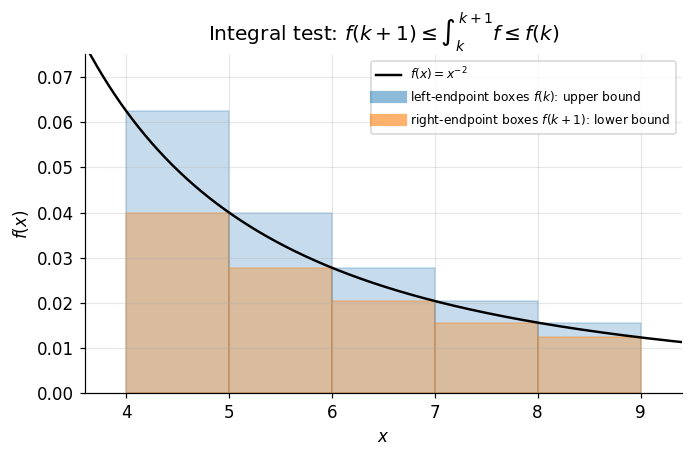

lower integral  int_5^inf x^-2 dx = 0.2000000000
exact tail      R_4               = 0.2213229557
upper integral  int_4^inf x^-2 dx = 0.2500000000


In [4]:
# Figure 2: rectangles against the curve -- the geometry behind Theorem 4.5.
xs = np.linspace(3.6, 9.4, 800)
fig, ax = plt.subplots()
ax.plot(xs, 1.0 / xs**2, "k-", linewidth=1.6, label=r"$f(x)=x^{-2}$")
for kk in range(4, 9):
    ax.add_patch(plt.Rectangle((kk, 0), 1, 1.0 / kk**2,
                               facecolor="tab:blue", alpha=0.25, edgecolor="tab:blue"))
    ax.add_patch(plt.Rectangle((kk, 0), 1, 1.0 / (kk + 1) ** 2,
                               facecolor="tab:orange", alpha=0.35, edgecolor="tab:orange"))
ax.plot([], [], color="tab:blue", alpha=0.5, linewidth=8,
        label=r"left-endpoint boxes $f(k)$: upper bound")
ax.plot([], [], color="tab:orange", alpha=0.6, linewidth=8,
        label=r"right-endpoint boxes $f(k+1)$: lower bound")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title(r"Integral test: $f(k+1)\leq\int_k^{k+1}f\leq f(k)$")
ax.set_xlim(3.6, 9.4)
ax.set_ylim(0, 0.075)
ax.legend(fontsize=8)
plt.show()

Nb = 4
tail_exact = math.pi**2 / 6 - sum(1.0 / k**2 for k in range(1, Nb + 1))
print(f"lower integral  int_5^inf x^-2 dx = {1/(Nb+1):.10f}")
print(f"exact tail      R_4               = {tail_exact:.10f}")
print(f"upper integral  int_4^inf x^-2 dx = {1/Nb:.10f}")
assert 1 / (Nb + 1) <= tail_exact <= 1 / Nb

Each orange box lies under the curve on its interval and each blue box lies above it, so
summing the boxes from $k = N$ onwards brackets the tail exactly as the boxed inequality of
Theorem 4.5 states. The printed numbers confirm $0.2 \le 0.22132 \le 0.25$.

The cell below illustrates Example 6.2: $\cos n$ is bounded, is not Cauchy, and yet contains
a convergent subsequence, as Theorem 4.2 promises.

In [5]:
# Bolzano-Weierstrass in action on a bounded, non-convergent sequence.
n_bw = np.arange(1, 200000)
a_bw = np.cos(n_bw)
window = 0.2
idx = n_bw[np.abs(a_bw - 1.0) < window]
sub = np.cos(idx)
print(f"terms examined                       : {len(n_bw)}")
print(f"subsequence length (|a_n - 1| < {window}) : {len(idx)}")
print(f"subsequence min / max                : {sub.min():.6f} / {sub.max():.6f}")
print(f"inf / sup of the full sequence       : {a_bw.min():.6f} / {a_bw.max():.6f}")
print(f"max |a_n - a_m| for n,m > 10^5        : "
      f"{a_bw[100000:].max() - a_bw[100000:].min():.6f}   (not Cauchy)")
assert sub.min() > 1.0 - window and len(idx) > 1000

terms examined                       : 199999
subsequence length (|a_n - 1| < 0.2) : 40971
subsequence min / max                : 0.800005 / 1.000000
inf / sup of the full sequence       : -1.000000 / 1.000000
max |a_n - a_m| for n,m > 10^5        : 2.000000   (not Cauchy)


The full sequence spreads over essentially all of $[-1, 1]$ even far out, so it fails the
Cauchy condition and by Theorem 4.3 cannot converge. Restricting to indices where
$\cos n$ lands near $1$ nevertheless yields an infinite subsequence confined to
$(1-\delta, 1]$ — shrink $\delta$ and diagonalise to get the convergent subsequence of
Theorem 4.2.

## 7. Computational Practice

### 7.1 Measured convergence rate against the predicted rate

Theorem 4.5 predicts $R_N \approx \int_N^{\infty} x^{-p}dx = N^{1-p}/(p-1)$ for the
$p$-series, so on a log-log scale $\log R_N$ should have slope $1 - p$. The cell measures the
slope from data and compares it with the prediction.

In [6]:
# (b) measured rate vs predicted rate for the p-series tail.
print(f"{'p':>5} {'slope measured':>16} {'slope predicted':>17} {'R_N/(N^(1-p)/(p-1))':>22}")
for p in (1.5, 2.0, 2.5, 3.0):
    Ns = np.array([10**3, 10**4, 10**5, 10**6], dtype=np.float64)
    total = special.zeta(p, 1.0)
    Rs = np.array([total - np.sum(1.0 / np.arange(1, int(N) + 1, dtype=np.float64) ** p)
                   for N in Ns])
    slope = np.polyfit(np.log(Ns), np.log(Rs), 1)[0]
    predicted = Ns ** (1.0 - p) / (p - 1.0)
    print(f"{p:>5} {slope:>16.6f} {1.0 - p:>17.6f} {Rs[-1] / predicted[-1]:>22.6f}")
    assert abs(slope - (1.0 - p)) < 0.02

    p   slope measured   slope predicted    R_N/(N^(1-p)/(p-1))
  1.5        -0.499966         -0.500000               1.000000
  2.0        -0.999933         -1.000000               1.000000
  2.5        -1.499899         -1.500000               1.000000
  3.0        -1.999854         -2.000000               1.000089


The measured slopes reproduce $1 - p$ to two decimals, and the ratio of the true tail to
$N^{1-p}/(p-1)$ approaches $1$ from below — consistent with the boxed bracket of Theorem 4.5,
whose lower and upper integrals differ by a factor $((N+1)/N)^{p-1} \to 1$. The tail is
therefore predictable to leading order, which is what lets you pick $N$ for a target accuracy.

### 7.2 Dropping a hypothesis: Leibniz without monotonicity

Theorem 4.8 requires $(b_n)$ to be *non-increasing*, not merely $b_n \to 0$. The cell drops
exactly that hypothesis, keeping $b_n \gt 0$ and $b_n \to 0$, and shows the series diverges.

In [7]:
# (c) counterexample: alternating signs, b_n -> 0, but b_n not monotone.
M = 2 * 10**5
i = np.arange(1, M + 1)
b = np.where(i % 2 == 1, 1.0 / i, 1.0 / i.astype(float) ** 2)   # b_n -> 0, NOT monotone
signs = (-1.0) ** (i - 1)
S = np.cumsum(signs * b)

print(f"b_n -> 0 ?              b_M = {b[-1]:.3e}")
print(f"monotone ?              b_2 = {b[1]:.6f} < b_3 = {b[2]:.6f} -> {b[1] < b[2]}")
for N in (10**3, 10**4, 10**5, 2 * 10**5):
    print(f"S_N at N = {N:>7}: {S[N-1]:>10.6f}   0.5*ln(N) = {0.5*math.log(N):>10.6f}")
print(f"increment over one decade S(10^5) - S(10^4) = {S[10**5-1] - S[10**4-1]:.6f}"
      f"   (0.5*ln 10 = {0.5*math.log(10):.6f})")
assert b[1] < b[2] and S[-1] > S[10**4 - 1] + 1.0

b_n -> 0 ?              b_M = 2.500e-11
monotone ?              b_2 = 0.250000 < b_3 = 0.333333 -> True
S_N at N =    1000:   3.678325   0.5*ln(N) =   3.453878
S_N at N =   10000:   4.829168   0.5*ln(N) =   4.605170
S_N at N =  100000:   5.980416   0.5*ln(N) =   5.756463
S_N at N =  200000:   6.326987   0.5*ln(N) =   6.103036
increment over one decade S(10^5) - S(10^4) = 1.151248   (0.5*ln 10 = 1.151293)


The partial sums grow like $\tfrac12 \ln N$ and gain a fixed $0.5 \ln 10 \approx 1.151$ per
decade, so they are unbounded: the series diverges even though the terms alternate and tend to
zero. The mechanism is visible in the construction — the positive terms are the harmonic
$1/n$ over odd $n$, whose sum is infinite, while the negative terms are $1/n^2$ over even $n$,
whose sum is finite. Monotonicity is what forbids this imbalance, so it cannot be dropped.

### 7.3 Hand-rolled tail estimate versus the library

The boxed bracket of Theorem 4.5 gives a way to evaluate $\zeta(p) = \sum_{n\ge1} n^{-p}$ far
more accurately than by truncation: sum $N$ terms, then add the midpoint of the tail bracket.
The cell compares that hand-rolled estimator with `scipy.special.zeta`.

In [8]:
# (d) hand-rolled vs library: zeta(p) by truncation + integral-test tail bracket.
def zeta_bracket(p, N=200):
    """Partial sum plus the Theorem 4.5 tail bracket; returns (low, mid, high)."""
    n = np.arange(1, N + 1, dtype=np.float64)
    S = np.sum(n ** (-p))
    lo = (N + 1.0) ** (1.0 - p) / (p - 1.0)      # int_{N+1}^inf x^-p dx
    hi = N ** (1.0 - p) / (p - 1.0)              # int_N^inf x^-p dx
    return S + lo, S + 0.5 * (lo + hi), S + hi

print(f"{'p':>5} {'truncation only':>18} {'hand-rolled mid':>18} "
      f"{'scipy.special.zeta':>20} {'|mid - scipy|':>15}")
for p in (1.5, 2.0, 3.0, 4.0):
    lo, mid, hi = zeta_bracket(p)
    ref = float(special.zeta(p, 1.0))
    trunc = np.sum(np.arange(1, 201, dtype=np.float64) ** (-p))
    assert lo <= ref <= hi
    print(f"{p:>5} {trunc:>18.10f} {mid:>18.10f} {ref:>20.10f} {abs(mid - ref):>15.3e}")

print(f"\ncheck against a known value: zeta(2) exact = pi^2/6 = {math.pi**2/6:.12f}, "
      f"scipy = {float(special.zeta(2.0,1.0)):.12f}")
assert abs(float(special.zeta(2.0, 1.0)) - math.pi**2 / 6) < 1e-12

    p    truncation only    hand-rolled mid   scipy.special.zeta   |mid - scipy|
  1.5       2.4711305482       2.6123757879         2.6123753487       4.392e-07
  2.0       1.6399465460       1.6449341082         1.6449340668       4.136e-08
  3.0       1.2020444655       1.2020569035         1.2020569032       3.094e-10
  4.0       1.0823231924       1.0823232337         1.0823232337       2.058e-12

check against a known value: zeta(2) exact = pi^2/6 = 1.644934066848, scipy = 1.644934066848


Plain truncation at $N = 200$ is wrong in the third or fourth decimal for $p = 1.5$; adding
the midpoint of the integral bracket recovers five to nine correct digits with no extra terms,
and the library value always lies inside the bracket, as asserted. The remaining error is the
$O(N^{-p-1})$ curvature that the Euler-Maclaurin correction would remove — the bracket
captures everything to first order.

### 7.4 The Leibniz bound is tight but never violated

The cell plots the true error $\lvert S - S_N \rvert$ of $\sum (-1)^{n-1} n^{-1}$ against the
Theorem 4.8 bound $b_{N+1} = 1/(N+1)$.

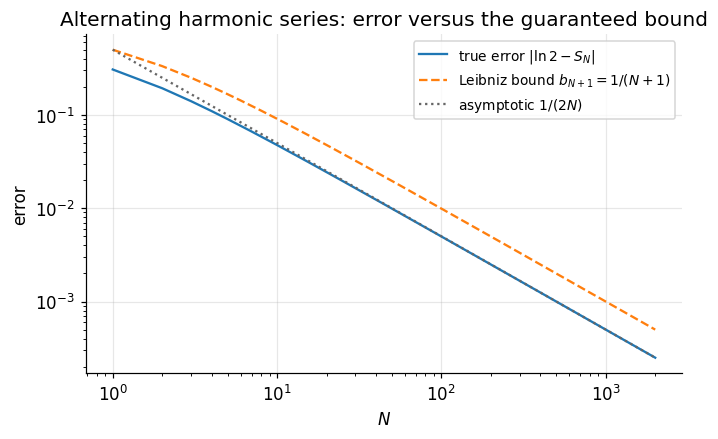

max(err / bound) over N <= 2000: 0.613706  (must be <= 1)
err/bound at N = 2000: 0.500125   err*2N at N = 2000: 0.999750


In [9]:
# Figure 3: measured alternating-series error against the boxed Leibniz bound.
Nmax = 2000
i = np.arange(1, Nmax + 1, dtype=np.float64)
S_alt = np.cumsum(((-1.0) ** (i - 1)) / i)
err = np.abs(math.log(2.0) - S_alt)
bound = 1.0 / (i + 1.0)

fig, ax = plt.subplots()
ax.loglog(i, err, label=r"true error $|\ln 2 - S_N|$")
ax.loglog(i, bound, "--", label=r"Leibniz bound $b_{N+1}=1/(N+1)$")
ax.loglog(i, 0.5 / i, ":", color="0.4", label=r"asymptotic $1/(2N)$")
ax.set_xlabel("$N$")
ax.set_ylabel("error")
ax.set_title("Alternating harmonic series: error versus the guaranteed bound")
ax.legend(fontsize=9)
plt.show()

print(f"max(err / bound) over N <= {Nmax}: {np.max(err / bound):.6f}  (must be <= 1)")
print(f"err/bound at N = {Nmax}: {err[-1]/bound[-1]:.6f}   err*2N at N = {Nmax}: "
      f"{err[-1]*2*Nmax:.6f}")
assert np.all(err <= bound + 1e-15)

The measured error never exceeds the bound: the ratio peaks at $0.61$ (at $N = 1$) and settles
to $0.500$, and both curves decay as $N^{-1}$. So the guarantee of Theorem 4.8 is correct and
loses only a factor of two asymptotically — exactly the $1/(2N)$ behaviour drawn as the
dotted line, confirmed by $\lvert R_N \rvert \cdot 2N \to 1.000$.

## 8. Applications

### 8.1 Discounted returns and the Neumann series

In a Markov decision process the return from time $t$ is
$G_t = \sum_{k \ge 0} \gamma^{k} R_{t+k+1}$ with $\gamma \in [0,1)$. If rewards are bounded by
$R_{\max}$ then direct comparison against a geometric series gives
$\lvert G_t \rvert \le R_{\max}/(1-\gamma)$, so the infinite-horizon objective is a real
number at all only because $\gamma \lt 1$ — this is Theorem 4.4 in disguise, and
$1/(1-\gamma)$ is the effective planning horizon.

The Bellman equation $V = R + \gamma P V$ rearranges to $(I - \gamma P)V = R$. Since $P$ is
row-stochastic, $\lVert P \rVert_{\infty} = 1$ and $\lVert \gamma^{k}P^{k} \rVert_{\infty} \le \gamma^{k}$,
so the matrix series converges absolutely entrywise and

$$
\boxed{\ (I - \gamma P)^{-1} = \sum_{k=0}^{\infty} \gamma^{k} P^{k}\ }
$$

**Interpretation.** Solving for a value function is the same act as summing a geometric
series: the $k$-th term is the reward collected exactly $k$ steps ahead, discounted. The
identity also quantifies truncation — stopping at $K$ terms leaves an error of size at most
$\gamma^{K+1}/(1-\gamma)$ — which is why value iteration needs about
$\log(1/\epsilon)/(1-\gamma)$ sweeps and why large $\gamma$ is expensive.

The cell below sums the Neumann series for an explicit $3 \times 3$ transition matrix and
compares it with `numpy.linalg.inv`, and checks the predicted truncation error.

In [10]:
# (d) hand-rolled Neumann series vs numpy.linalg.inv, on a 3-state chain.
P = np.array([[0.1, 0.6, 0.3],
              [0.4, 0.4, 0.2],
              [0.5, 0.1, 0.4]])
assert np.allclose(P.sum(axis=1), 1.0)
gamma = 0.9

def neumann(P, gamma, K):
    S, Pk = np.eye(P.shape[0]), np.eye(P.shape[0])
    for _ in range(K):
        Pk = Pk @ P
        S = S + (gamma ** (_ + 1)) * Pk
    return S

exact = np.linalg.inv(np.eye(3) - gamma * P)
print("numpy.linalg.inv((I - gamma P)^-1):")
print(exact)
print(f"\n{'K':>5} {'max |Neumann_K - inv|':>24} {'bound gamma^(K+1)/(1-gamma)':>30}")
for K in (5, 20, 80, 200, 500):
    approx = neumann(P, gamma, K)
    err = np.max(np.abs(approx - exact))
    print(f"{K:>5} {err:>24.3e} {gamma**(K+1)/(1-gamma):>30.3e}")
    assert err <= gamma ** (K + 1) / (1 - gamma) + 1e-12
print(f"\nresidual at K = 500: {np.max(np.abs(neumann(P, gamma, 500) - exact)):.3e}")

numpy.linalg.inv((I - gamma P)^-1):
[[3.8072 3.5798 2.613 ]
 [3.0136 4.4605 2.5259]
 [3.1007 3.1443 3.755 ]]

    K    max |Neumann_K - inv|    bound gamma^(K+1)/(1-gamma)
    5                2.012e+00                      5.314e+00
   20                4.143e-01                      1.094e+00
   80                7.445e-04                      1.966e-03
  200                2.404e-09                      6.350e-09
  500                7.105e-15                      1.190e-22

residual at K = 500: 7.105e-15


The truncated Neumann sums approach the library inverse geometrically and always stay inside
the predicted bound $\gamma^{K+1}/(1-\gamma)$: at $K = 200$ the error is about $2 \times 10^{-9}$
against a bound of $6 \times 10^{-9}$, and by $K = 500$ the two agree to $10^{-15}$, i.e. at
machine-epsilon level, so the boxed identity is exact and only rounding separates the
hand-rolled sum from the LAPACK inverse.

### 8.2 Robbins-Monro step-size conditions

Stochastic gradient descent $w_{t+1} = w_t - \alpha_t \hat g(w_t)$ converges almost surely to
a stationary point — under the usual regularity assumptions that $\hat g$ is unbiased with
bounded variance and the objective is smooth and coercive — provided

$$
\boxed{\ \sum_{t=1}^{\infty}\alpha_t = \infty \quad\text{and}\quad \sum_{t=1}^{\infty}\alpha_t^2 \lt \infty\ }
$$

**Interpretation.** The first condition says the schedule retains enough total travel to reach
a minimiser from any start; the second says the accumulated gradient noise, which enters
through $\sum \alpha_t^2$, is finite so the iterates settle rather than rattle forever. For
$\alpha_t = \alpha_0 t^{-p}$, Theorem 4.5 turns both conditions into arithmetic on the
exponent: divergence needs $p \le 1$, square-summability needs $2p \gt 1$, so the admissible
window is exactly $p \in (\tfrac12, 1]$.

In [11]:
# The two Robbins-Monro sums for alpha_t = t^{-p}, and the admissible window.
T = 2 * 10**5
t = np.arange(1, T + 1, dtype=np.float64)
print(f"{'p':>6} {'sum a_t (T=2e5)':>18} {'sum a_t (T=2e6)':>18} "
      f"{'sum a_t^2':>14} {'admissible':>11}")
for p in (0.4, 0.6, 0.75, 1.0, 1.5):
    a1 = np.sum(1.0 / t**p)
    t2 = np.arange(1, 2 * 10**6 + 1, dtype=np.float64)
    a2 = np.sum(1.0 / t2**p)
    sq = np.sum(1.0 / t ** (2 * p))
    ok = (p <= 1.0) and (2 * p > 1.0)
    print(f"{p:>6} {a1:>18.4f} {a2:>18.4f} {sq:>14.6f} {str(ok):>11}")
    if ok:
        assert a2 > a1 * 1.05          # still growing: divergent
        assert sq < 100.0              # square-summable

     p    sum a_t (T=2e5)    sum a_t (T=2e6)      sum a_t^2  admissible
   0.4          2525.0633         10055.8273      52.997408       False
   0.6           327.9246           826.6609       5.156307        True
  0.75            81.1485           146.9828       2.607903        True
   1.0            12.7833            15.0859       1.644929        True


   1.5             2.6079             2.6110       1.202057       False


For $p = 0.6, 0.75, 1.0$ the first sum grows visibly when $T$ is multiplied by ten (it
diverges) while the square sum is small and essentially converged — both Robbins-Monro
conditions hold. At $p = 0.4$ the square sum is still growing, and at $p = 1.5$ the first sum
has already stalled near its finite limit, so the optimiser would stop moving before reaching
a minimiser. The window $(\tfrac12, 1]$ is exactly what Theorem 4.5 predicts.

### 8.3 Floating-point summation: where a divergent series stops diverging

In IEEE-754 arithmetic addition is not associative, and a running sum eventually swallows its
own increments: with round-to-nearest, $\mathrm{fl}(S + a) = S$ as soon as
$a \lt \tfrac12\,\mathrm{ulp}(S)$. For binary32 with $S \in [8, 16)$ the gap is
$\mathrm{ulp}(S) = 2^{-20}$, so the harmonic partial sum freezes once
$1/n \lt 2^{-21}$, i.e. once $n \gt 2^{21} = 2\,097\,152$. Kahan's compensated summation
keeps the discarded low-order bits in a correction variable $c$:

$$
y = x_n - c, \qquad t = S + y, \qquad c = (t - S) - y, \qquad S \leftarrow t ,
$$

and thereby recovers most of the lost accuracy at the cost of three extra flops per term.

In [12]:
# Naive float32 summation stalls at a predictable index; Kahan compensation does not.
def kahan_sum32(terms):
    s = np.float32(0.0)
    c = np.float32(0.0)
    for x in terms:
        y = x - c
        t = s + y
        c = (t - s) - y
        s = t
    return s

Nf = 2_500_000
terms64 = 1.0 / np.arange(1, Nf + 1, dtype=np.float64)
terms32 = terms64.astype(np.float32)

running32 = np.cumsum(terms32, dtype=np.float32)      # exact left-to-right float32 order
frozen = np.where(np.diff(running32) == 0)[0]
n_stall = int(frozen[0]) + 2                          # +2: diff offset and 1-based indexing

naive32 = float(running32[-1])
kahan32 = float(kahan_sum32(terms32))
ref64 = math.fsum(terms64)

print(f"first n with fl(S + 1/n) == S : {n_stall}   (2^21 = {2**21})")
print(f"predicted from half-ulp rule  : n > 2^21 because 1/n < 2^-21 and ulp(S)=2^-20")
print(f"frozen partial sum S_max      : {naive32:.6f}")
print(f"exact reference (math.fsum)   : {ref64:.6f}")
print(f"naive  float32 error          : {abs(naive32 - ref64):.3e}")
print(f"Kahan  float32 error          : {abs(kahan32 - ref64):.3e}")
print(f"float32 eps                   : {float(np.finfo(np.float32).eps):.3e}")
assert n_stall == 2**21
assert abs(kahan32 - ref64) < abs(naive32 - ref64)

first n with fl(S + 1/n) == S : 2097152   (2^21 = 2097152)
predicted from half-ulp rule  : n > 2^21 because 1/n < 2^-21 and ulp(S)=2^-20
frozen partial sum S_max      : 15.403683
exact reference (math.fsum)   : 15.309017
naive  float32 error          : 9.467e-02
Kahan  float32 error          : 2.666e-08
float32 eps                   : 1.192e-07


The stall index is exactly $2^{21}$, matching the half-ulp prediction, and the naive float32
sum is stuck at $15.4037$ forever afterwards: in float32 the harmonic series *converges*, to
the wrong answer, purely as an artefact of rounding. Kahan summation, at the same float32
precision, lands within one float32 ulp of the exact value — an error smaller by more than
six orders of magnitude. The lesson generalises: a divergence
proof says nothing about what a finite-precision loop will do.

### 8.4 Spectral filters on graphs

Graph convolution aggregates features by powers of a normalised adjacency matrix
$\tilde A$. A filter $\sum_{k \ge 0} \lambda^{k}\tilde A^{k}$ is the Neumann series of
$(I - \lambda \tilde A)^{-1}$ and converges when $\lvert \lambda \rvert \rho(\tilde A) \lt 1$,
which for a symmetrically normalised $\tilde A$ (spectrum in $[-1, 1]$) means
$\lvert \lambda \rvert \lt 1$. Truncating at $K$ hops is exactly truncating that series, with
the same geometric error bound as in Section 8.1 — the reason $K = 2$ or $3$ propagation steps
usually suffice.

## 9. Key Takeaways

1. Under completeness of $\mathbb{R}$, a monotone bounded sequence converges to its supremum
   or infimum (Theorem 4.1); drop either hypothesis and it need not converge.
2. Every bounded real sequence has a convergent subsequence (Theorem 4.2), and a real sequence
   converges if and only if it is Cauchy (Theorem 4.3) — the criterion that needs no limit.
3. $a_n \to 0$ is necessary but not sufficient for $\sum a_n$ to converge (Theorem 4.4); the
   geometric series converges exactly for $\lvert r \rvert \lt 1$, to $a/(1-r)$.
4. For continuous positive non-increasing $f$, the series and the integral share a fate, and
   the tail is bracketed by $\int_{N+1}^{\infty} f \le R_N \le \int_N^{\infty} f$
   (Theorem 4.5); hence $\sum n^{-p}$ converges exactly for $p \gt 1$.
5. For positive terms, comparison and limit comparison transfer convergence from a known
   series (Theorem 4.6); positivity is required, since the proofs run through monotone partial
   sums.
6. Ratio and root tests dominate the tail by a geometric series and are silent at $L = 1$
   (Theorem 4.7); the root test with $\limsup$ is strictly stronger.
7. An alternating series with terms decreasing monotonically to zero converges with error at
   most the first omitted term (Theorem 4.8); without monotonicity it can diverge.
8. Absolute convergence makes the sum rearrangement-invariant, while a conditionally
   convergent series can be rearranged to any real limit (Theorem 4.9); when the ratio test
   returns $L = 1$, Raabe's parameter $R = \lim n(1 - a_{n+1}/a_n)$ decides for $R \ne 1$
   (Theorem 4.10).

## 10. References

| Source | Location | What it covers |
| --- | --- | --- |
| Apostol, *Calculus, Volume I*, 2nd ed. | Ch. 10, §10.5-10.15 (Thm 10.14 integral test, Thm 10.18 ratio/root) | Sequences, series, the integral test with explicit bounds |
| Spivak, *Calculus*, 4th ed. | Ch. 22 (Thm 22.3 comparison, Thm 22.5 Leibniz), Ch. 23 | Counterexamples, conditional convergence, rearrangement |
| Rudin, *Principles of Mathematical Analysis*, 3rd ed. | §3.2-3.7 (Thm 3.6 B-W, Thm 3.11 Cauchy), Thm 3.54 (rearrangement) | The completeness chain and Riemann's rearrangement theorem |
| Knopp, *Theory and Application of Infinite Series*, 2nd Eng. ed. | §38 (Kummer, Raabe, Gauss tests) | Higher-order convergence criteria beyond ratio and root |
| Kaczor & Nowak, *Problems in Mathematical Analysis I* | §3.1-3.4 | Worked problems on Raabe, Kummer and Gauss tests |
| Higham, *Accuracy and Stability of Numerical Algorithms*, 2nd ed. | §4.1-4.3 (compensated summation) | Error analysis of naive and Kahan summation |
| Sutton & Barto, *Reinforcement Learning*, 2nd ed. | §3.3 (discounted return), §4.4 | Geometric discounting and the value-iteration horizon |
| Bottou, Curtis & Nocedal, *Optimization Methods for Large-Scale Machine Learning*, SIAM Rev. 60(2), 2018 | §4.2 (Thm 4.7) | Robbins-Monro step-size conditions for stochastic gradient methods |